# Ensemble — Full Model Comparison: Out-of-Sample Results

In [29]:
%matplotlib inline
import sys
sys.path.insert(0, '/Users/maxzhalilo/Personal/kalshi/kalshi-carry/kalshi-weather/neural-net')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

import evaluation
import config as cfg

df1 = pd.read_csv('checkpoints/model1_preds_test.csv', parse_dates=['date'])
df2 = pd.read_csv('checkpoints/model2_preds_test.csv', parse_dates=['date'])
df3 = pd.read_csv('checkpoints/model3_preds_test.csv', parse_dates=['date'])
df_ens = pd.read_csv('checkpoints/ensemble_preds_test.csv', parse_dates=['date'])

print(f'Model 1: {len(df1)} rows')
print(f'Model 2: {len(df2)} rows')
print(f'Model 3: {len(df3)} rows')
print(f'Ensemble: {len(df_ens)} rows')
print(f'Date range: {df_ens.date.min()} to {df_ens.date.max()}')

Model 1: 2120 rows
Model 2: 2120 rows
Model 3: 2120 rows
Ensemble: 2120 rows
Date range: 2026-01-01 00:00:00 to 2026-04-16 00:00:00


## Comparison Metrics — Side-by-Side

In [30]:
rows = []
for name, df, mu_col in [
    ('Model 1 (Forecast)', df1, 'mu'),
    ('Model 2 (Historical)', df2, 'mu'),
    ('Model 3 (Market)', df3, 'mu'),
    ('Ensemble', df_ens, 'ensemble_mu'),
]:
    m = evaluation.compute_metrics(df['y_true'].values, df[mu_col].values)
    m['model'] = name
    rows.append(m)

comparison = pd.DataFrame(rows).set_index('model')
comparison[['mae', 'rmse', 'bias', 'r2', 'corr', 'n']].round(4)

,mae,rmse,bias,r2,corr,n
model,,,,,,
Model 1 (Forecast),1.2201,1.6582,0.0315,0.9923,0.9962,2120
Model 2 (Historical),5.1800,6.8779,0.3980,0.8668,0.9318,2120
Model 3 (Market),3.2989,4.3130,-2.0626,0.9476,0.9803,2120
Ensemble,1.2198,1.6574,0.0290,0.9923,0.9962,2120


## Per-City Comparison — Best Model per City

In [31]:
city_dfs = {}
for name, df, mu_col in [
    ('Model 1', df1, 'mu'),
    ('Model 2', df2, 'mu'),
    ('Model 3', df3, 'mu'),
    ('Ensemble', df_ens, 'ensemble_mu'),
]:
    cm = evaluation.metrics_by_city(df, y_true_col='y_true', y_pred_col=mu_col)
    city_dfs[name] = cm.set_index('ticker')['mae'].rename(f'{name} MAE')

city_compare = pd.concat(city_dfs.values(), axis=1)
city_compare['best_model'] = city_compare.idxmin(axis=1).str.replace(' MAE', '')
# Add city names
city_compare.index = [cfg.CITIES.get(t, (t,))[0] for t in city_compare.index]
city_compare.round(3)

,Model 1 MAE,Model 2 MAE,Model 3 MAE,Ensemble MAE,best_model
Las Vegas,0.657,3.162,3.611,0.657,Model 1
Phoenix,0.913,2.933,3.302,0.912,Ensemble
Oklahoma City,0.922,6.775,3.856,0.921,Ensemble
Dallas,0.931,4.732,3.804,0.932,Model 1
Miami,0.932,2.908,1.788,0.932,Ensemble
Atlanta,0.954,4.928,2.806,0.954,Ensemble
San Antonio,1.002,5.022,3.646,1.003,Model 1
Houston,1.074,4.078,2.796,1.076,Model 1
New Orleans,1.078,4.182,2.927,1.078,Ensemble
Seattle,1.079,3.315,2.554,1.078,Ensemble


## Ensemble Weight Distribution

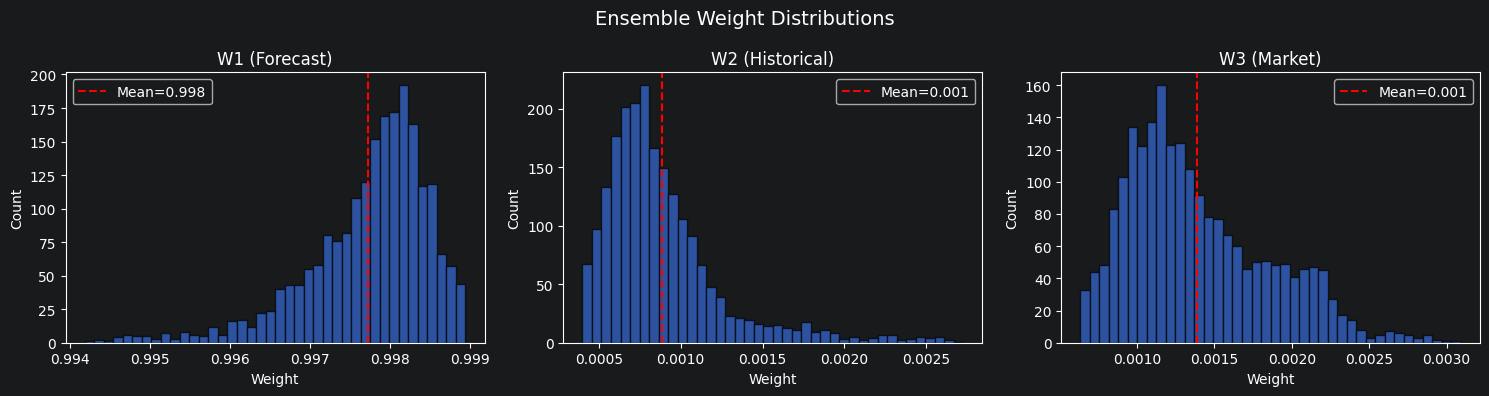

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, ['w1_forecast', 'w2_historical', 'w3_market'],
                          ['W1 (Forecast)', 'W2 (Historical)', 'W3 (Market)']):
    ax.hist(df_ens[col], bins=40, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Weight')
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.axvline(df_ens[col].mean(), color='red', linestyle='--',
               label=f'Mean={df_ens[col].mean():.3f}')
    ax.legend()
plt.suptitle('Ensemble Weight Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Weight Variation by Season (Average Weights by Month)

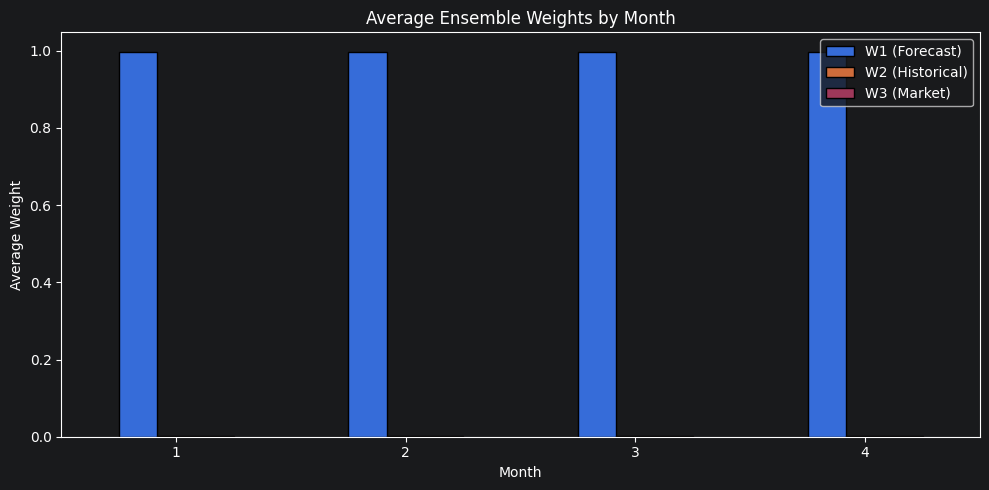

,w1_forecast,w2_historical,w3_market
month,,,
1,0.9976,0.0008,0.0016
2,0.9979,0.0008,0.0013
3,0.9978,0.0010,0.0013
4,0.9974,0.0012,0.0014


In [33]:
df_ens_copy = df_ens.copy()
df_ens_copy['month'] = df_ens_copy['date'].dt.month

monthly_weights = df_ens_copy.groupby('month')[['w1_forecast', 'w2_historical', 'w3_market']].mean()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_weights.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_xlabel('Month')
ax.set_ylabel('Average Weight')
ax.set_title('Average Ensemble Weights by Month')
ax.legend(['W1 (Forecast)', 'W2 (Historical)', 'W3 (Market)'])
ax.set_xticklabels(monthly_weights.index, rotation=0)
plt.tight_layout()
plt.show()

monthly_weights.round(4)

## Calibration Comparison — All 4 Models

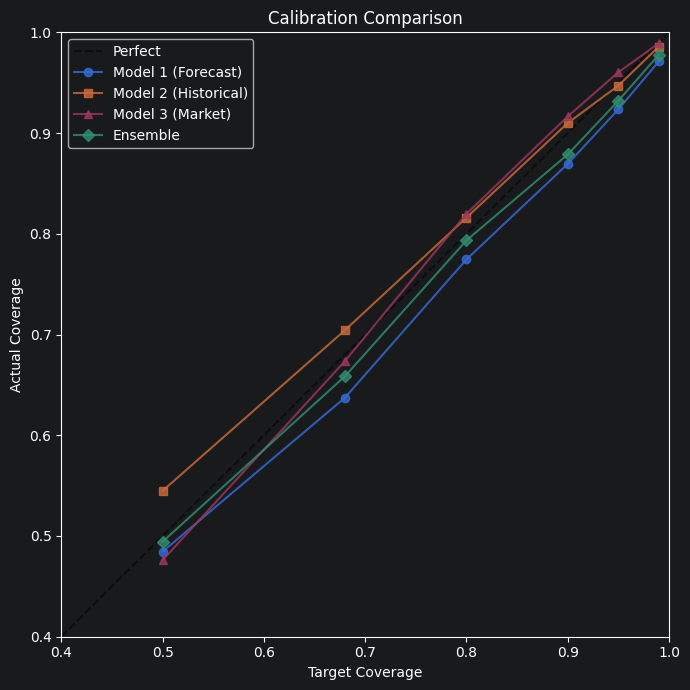

In [34]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')

for name, df, mu_col, sigma_col, marker in [
    ('Model 1 (Forecast)', df1, 'mu', 'sigma', 'o'),
    ('Model 2 (Historical)', df2, 'mu', 'sigma', 's'),
    ('Model 3 (Market)', df3, 'mu', 'sigma', '^'),
    ('Ensemble', df_ens, 'ensemble_mu', 'ensemble_sigma', 'D'),
]:
    cal = evaluation.calibration_check(df['y_true'].values, df[mu_col].values, df[sigma_col].values)
    ax.plot(cal['target_coverage'], cal['actual_coverage'], f'{marker}-', label=name, alpha=0.8)

ax.set_xlabel('Target Coverage')
ax.set_ylabel('Actual Coverage')
ax.set_title('Calibration Comparison')
ax.legend()
ax.set_xlim(0.4, 1.0)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

## Ensemble Time Series — NY, Phoenix, Miami

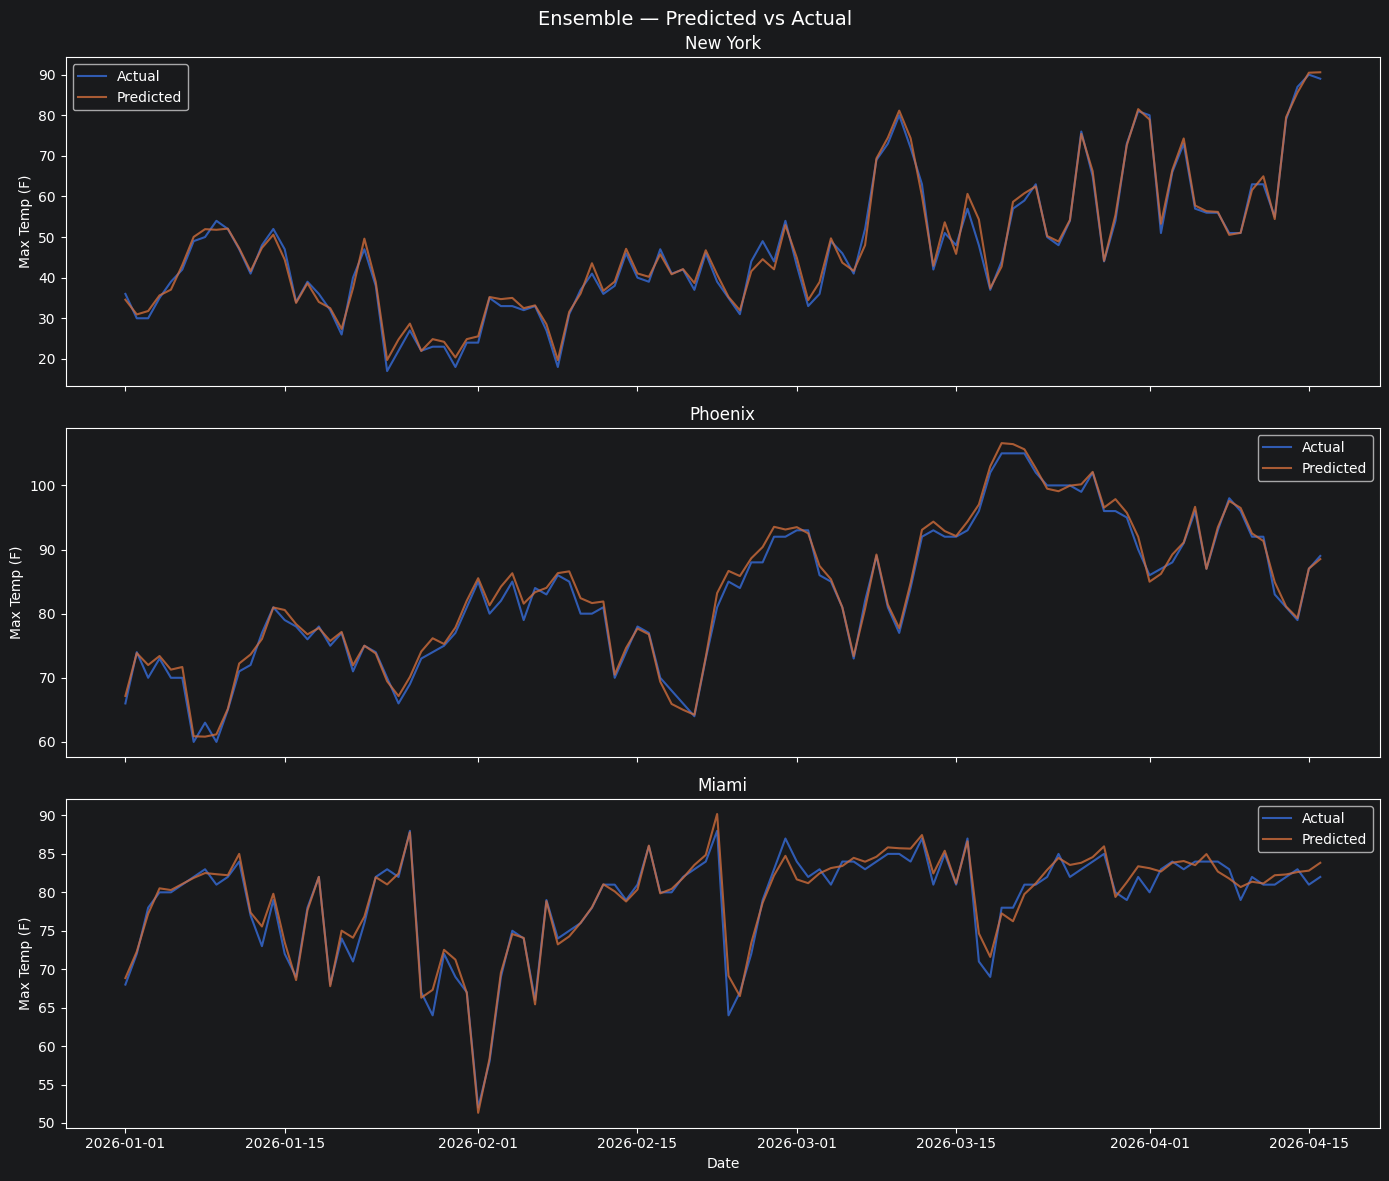

In [35]:
fig = evaluation.plot_timeseries(
    df_ens, y_true_col='y_true', y_pred_col='ensemble_mu',
    cities=['KXHIGHNY', 'KXHIGHTPHX', 'KXHIGHMIA'],
    title='Ensemble — Predicted vs Actual'
)
plt.show()

## Bucket Probability Example

Sample: city=KXHIGHAUS, date=2026-01-01 00:00:00, mu=74.24, sigma=1.06, y_true=74.0


,bucket,probability,fair_value_cents
11,70-75,0.7653,76
12,75-80,0.2347,23


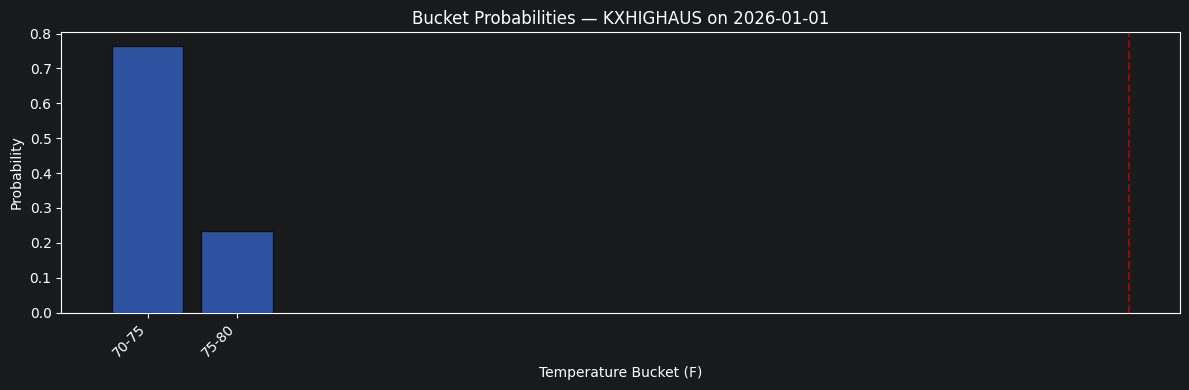

In [36]:
# Pick a sample row from ensemble predictions
sample = df_ens.iloc[0]
print(f"Sample: city={sample['ticker']}, date={sample['date']}, "
      f"mu={sample['ensemble_mu']:.2f}, sigma={sample['ensemble_sigma']:.2f}, "
      f"y_true={sample['y_true']:.1f}")

# Define temperature buckets (5-degree bins from 20F to 120F)
bucket_edges = []
bucket_labels = []
bucket_edges.append((float('-inf'), 20))
bucket_labels.append('<20')
for lo in range(20, 115, 5):
    bucket_edges.append((lo, lo + 5))
    bucket_labels.append(f'{lo}-{lo+5}')
bucket_edges.append((120, float('inf')))
bucket_labels.append('>120')

probs = evaluation.gaussian_bucket_probs(
    mu=sample['ensemble_mu'], sigma=sample['ensemble_sigma'],
    bucket_edges=bucket_edges
)

# Fair value in cents
fair_values = [evaluation.fair_value_cents(p) for p in probs]

bucket_df = pd.DataFrame({
    'bucket': bucket_labels,
    'probability': probs,
    'fair_value_cents': fair_values
})

# Only show buckets with meaningful probability
bucket_df_show = bucket_df[bucket_df['probability'] > 0.001].copy()
display(bucket_df_show.round(4))

# Plot bucket probabilities
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(bucket_df_show['bucket'], bucket_df_show['probability'],
       edgecolor='black', alpha=0.7)
ax.set_xlabel('Temperature Bucket (F)')
ax.set_ylabel('Probability')
ax.set_title(f"Bucket Probabilities — {sample['ticker']} on {sample['date'].date()}")
ax.axvline(x=bucket_df_show.index[bucket_df_show['probability'].argmax()],
           color='red', linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## MAE Heatmap — Ensemble

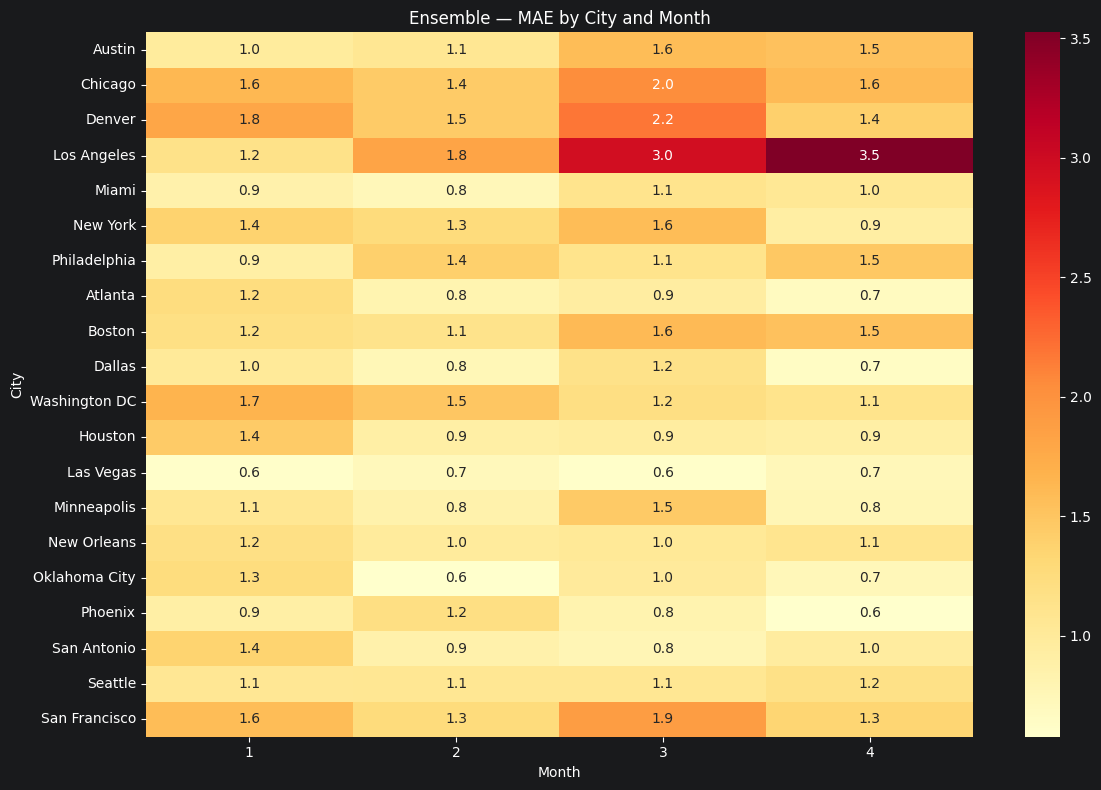

In [37]:
fig = evaluation.plot_mae_heatmap(
    df_ens, y_true_col='y_true', y_pred_col='ensemble_mu',
    title='Ensemble — MAE by City and Month'
)
plt.show()